In [4]:
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt

# Set global Seaborn style
sns.set_theme(
    style="whitegrid",   # or "ticks" for minimalist look
    context="paper",     # "notebook", "talk", "poster", "paper"
    font="DejaVu Sans"
)

%config InlineBackend.figure_format = 'retina'


KeyboardInterrupt: 

eigenvalue: Pearson=-0.633, Spearman=-0.668, p=0.000516


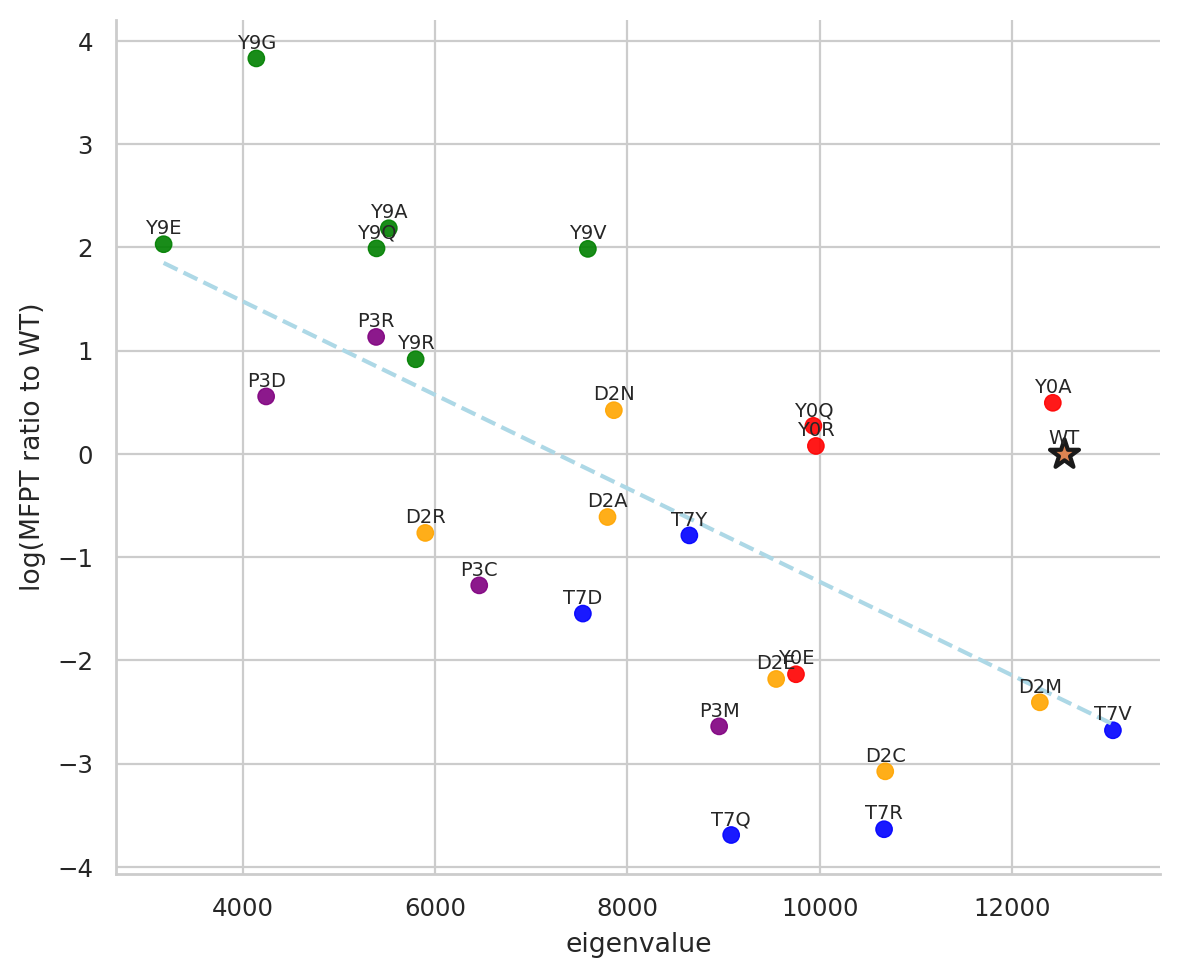

⚠️ Warning: dropped 1 rows with missing values for abs_dvar_F
abs_dvar_F: Pearson=0.712, Spearman=0.622, p=6.53e-05


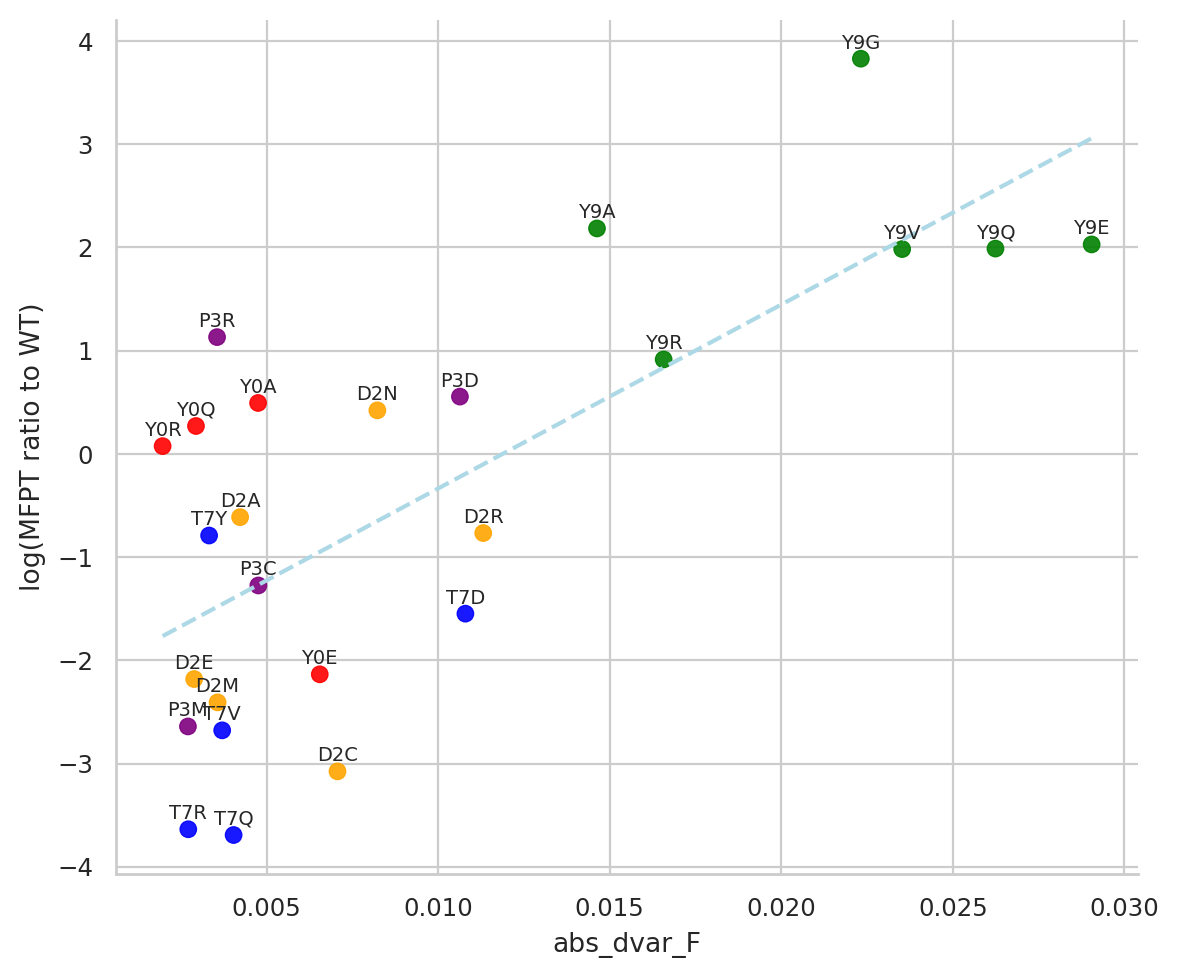

(np.float64(0.7120922610695047), np.float64(0.6223076923076922))

In [ ]:
import pickle
from scipy import stats
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from common.utils import collect_df  
from common.consts import res_colors

def plot_mfpt_corr(df, prop_col, wt_label='WT', group_col='residue_idx', th=None, log_prop=True):
    wt_mfpt = float(df.loc[wt_label, 'mfpt'])
    wt_prop = df.loc[wt_label, prop_col]

    # Build x/y arrays
    x_all = df[prop_col].to_numpy()
    y_all = np.log(wt_mfpt / df['mfpt'].to_numpy())
    names = df.index.to_numpy()

    # Mask out NaNs
    mask = ~(np.isnan(x_all) | np.isnan(y_all))
    if mask.sum() < len(x_all):
        print(f"⚠️ Warning: dropped {len(x_all) - mask.sum()} rows with missing values for {prop_col}")

    x_valid = x_all[mask]
    y_valid = y_all[mask]

    pearson, p = stats.pearsonr(x_valid, y_valid)
    spearman, _ = stats.spearmanr(x_valid, y_valid)
    print(f"{prop_col}: Pearson={pearson:.3f}, Spearman={spearman:.3f}, p={p:.3g}")

    # Prepare plotting DataFrame (with NaNs included so scatter still shows them if needed)
    plot_df = df.copy()
    plot_df["xval"] = x_all
    plot_df["yval"] = y_all
    plot_df["group"] = plot_df[group_col].astype("Int64")

    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        data=plot_df,
        x="xval", y="yval",
        hue="group",
        palette={k: res_colors.get(int(k)) for k in plot_df["group"].dropna().unique()},
        s=35, alpha=0.9, edgecolor=None
    )

    sns.regplot(
        x=x_valid, y=y_valid,
        scatter=False, color="lightblue", ci=None,
        line_kws={"lw":1.5, "ls":"--"}
    )

    plt.scatter(wt_prop, 0, s=120,
                marker="*", edgecolors="k", linewidths=1.5, label=wt_label)

    for xv, yv, name in zip(x_all, y_all, names):
        if not (np.isnan(xv) or np.isnan(yv)):
            plt.text(xv, yv + 0.06, name, fontsize=7, ha="center", va="bottom")

    xlabel = (prop_col)
    plt.xlabel(xlabel)
    plt.ylabel("log(MFPT ratio to WT)")

    # plt.legend(title="Residue", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.legend([],[], frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.show()

    return pearson, spearman


with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

thresholds = np.array(list(all_mfpt['chignolin'].keys()))
df = collect_df(True, all_mfpt, thresholds[1])
plot_mfpt_corr(df, "eigenvalue")
plot_mfpt_corr(df, "abs_dvar_F")


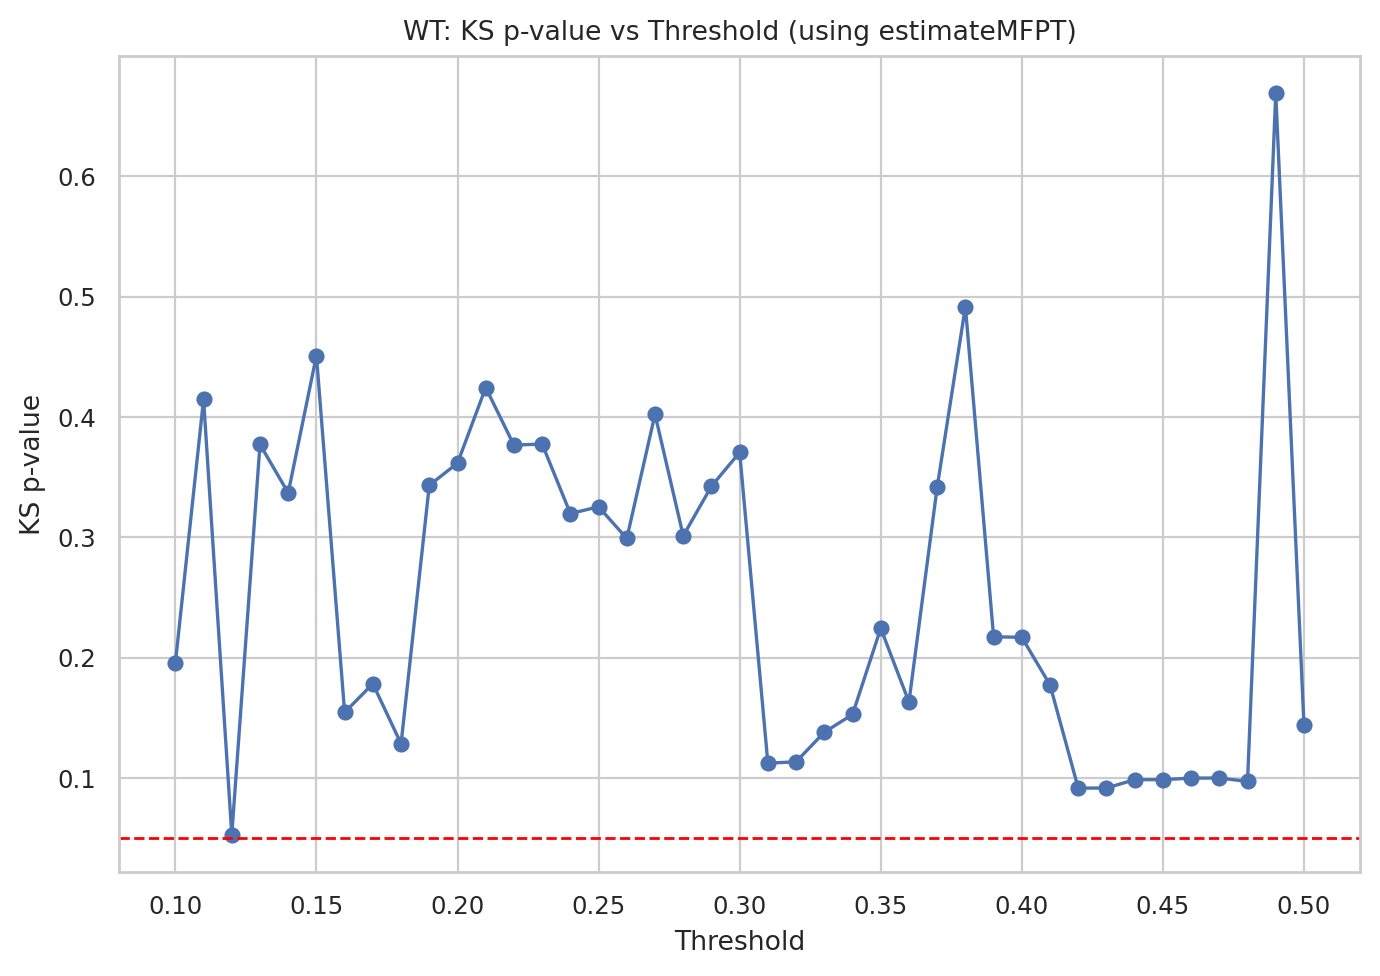

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from scipy import stats
from common.utils import estimateMFPT

with open("../data/mfpt-pace=25000-granular.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

def plot_wt_p_vs_threshold(all_mfpt):
    ths = np.array(sorted(all_mfpt['chignolin'].keys(), key=float), dtype=float)

    pvals, mfpts, ks = [], [], []
    for th in ths:
        s = np.array(all_mfpt['chignolin'][th])
        mfpt, k = estimateMFPT(s)         # get MFPT and how many samples it kept
        sub = np.sort(s)
        sub = s[:k]                       # use only those k fastest samples
        tau = sub.mean()                  # exponential MLE
        _, p = stats.kstest(sub, "expon", args=(0, tau))  # one-sample KS test
        pvals.append(p)
        mfpts.append(mfpt)
        ks.append(k)

    df = pd.DataFrame({
        "threshold": ths,
        "p": pvals,
        "mfpt": mfpts,
        "k_used": ks
    }).set_index("threshold")

    plt.figure(figsize=(7, 5))
    plt.plot(df.index, df["p"], marker="o")
    plt.axhline(0.05, linestyle="--", color="red", linewidth=1)
    plt.xlabel("Threshold")
    plt.ylabel("KS p-value")
    plt.title("WT: KS p-value vs Threshold (using estimateMFPT)")
    plt.tight_layout()
    plt.show()

    return df

df_wt_p = plot_wt_p_vs_threshold(all_mfpt)


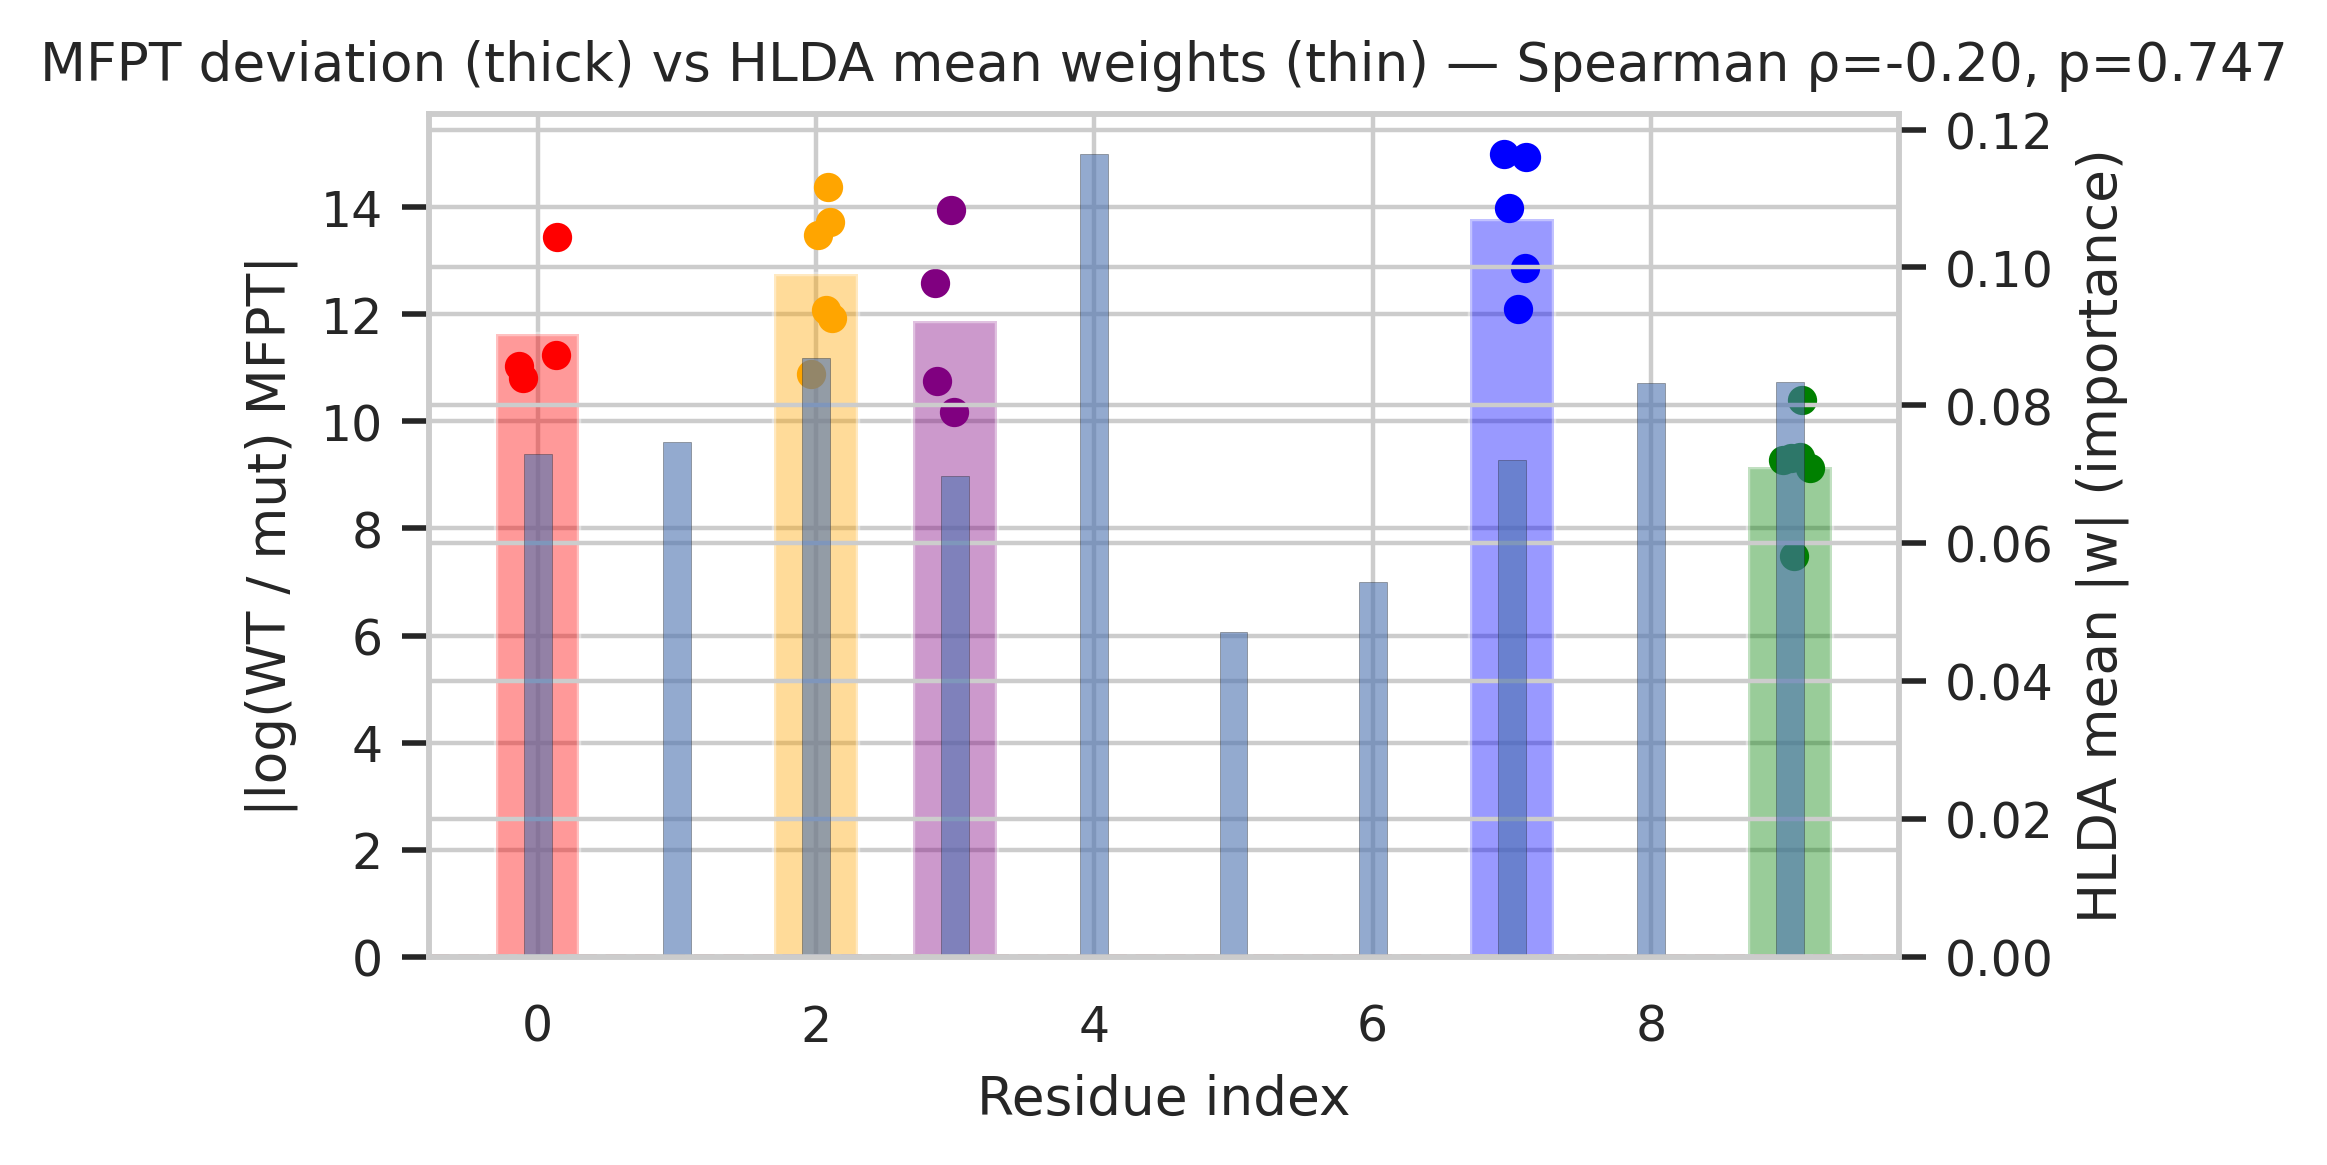

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

thresholds = np.array(list(all_mfpt['chignolin'].keys()))
df = collect_df(True, all_mfpt, thresholds[1])
importance = {4:0.1165, 2:0.0868, 9:0.0834, 8:0.0833, 1:0.0747, 0:0.0730, 7:0.0720, 3:0.0697, 6:0.0544, 5:0.0471}

wt = float(df.loc['WT', 'mfpt'])

med_abs = {}
dist_by_res = {}
for i, g in df.groupby("residue_idx"):
    i = int(i)
    r = np.log(g['mfpt'].to_numpy())
    d = np.abs(r)
    med_abs[i] = np.mean(d)
    dist_by_res[i] = d

residues = sorted(set(range(10)) | set(importance.keys()) | set(med_abs.keys()))

fig, ax = plt.subplots(figsize=(5,3), dpi=200)
for i in residues:
    if i in med_abs:
        ax.bar(i, med_abs[i], color=res_colors[i], alpha=0.4, width=0.6)
        d = dist_by_res[i]
        x_jitter = np.random.uniform(-0.15, 0.15, size=len(d))
        ax.scatter(np.full(len(d), i) + x_jitter, d, color=res_colors[i], s=20, zorder=3)

ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel("Residue index")
ax.set_ylabel("|log(WT / mut) MFPT|")

ax2 = ax.twinx()
imp_vals = [importance.get(i, np.nan) for i in residues]
ax2.bar(residues, imp_vals, width=0.2, alpha=0.6, edgecolor='k', linewidth=0.1)
ax2.set_ylabel("HLDA mean |w| (importance)")

x = np.array([med_abs.get(i, np.nan) for i in residues], float)
y = np.array([importance.get(i, np.nan) for i in residues], float)
mask = ~np.isnan(x) & ~np.isnan(y)
rho, p = spearmanr(x[mask], y[mask]) if mask.any() and mask.sum()>1 else (np.nan, np.nan)
ax.set_title(f"MFPT deviation (thick) vs HLDA mean weights (thin) — Spearman ρ={rho:.2f}, p={p:.3g}")

fig.tight_layout()
plt.show()


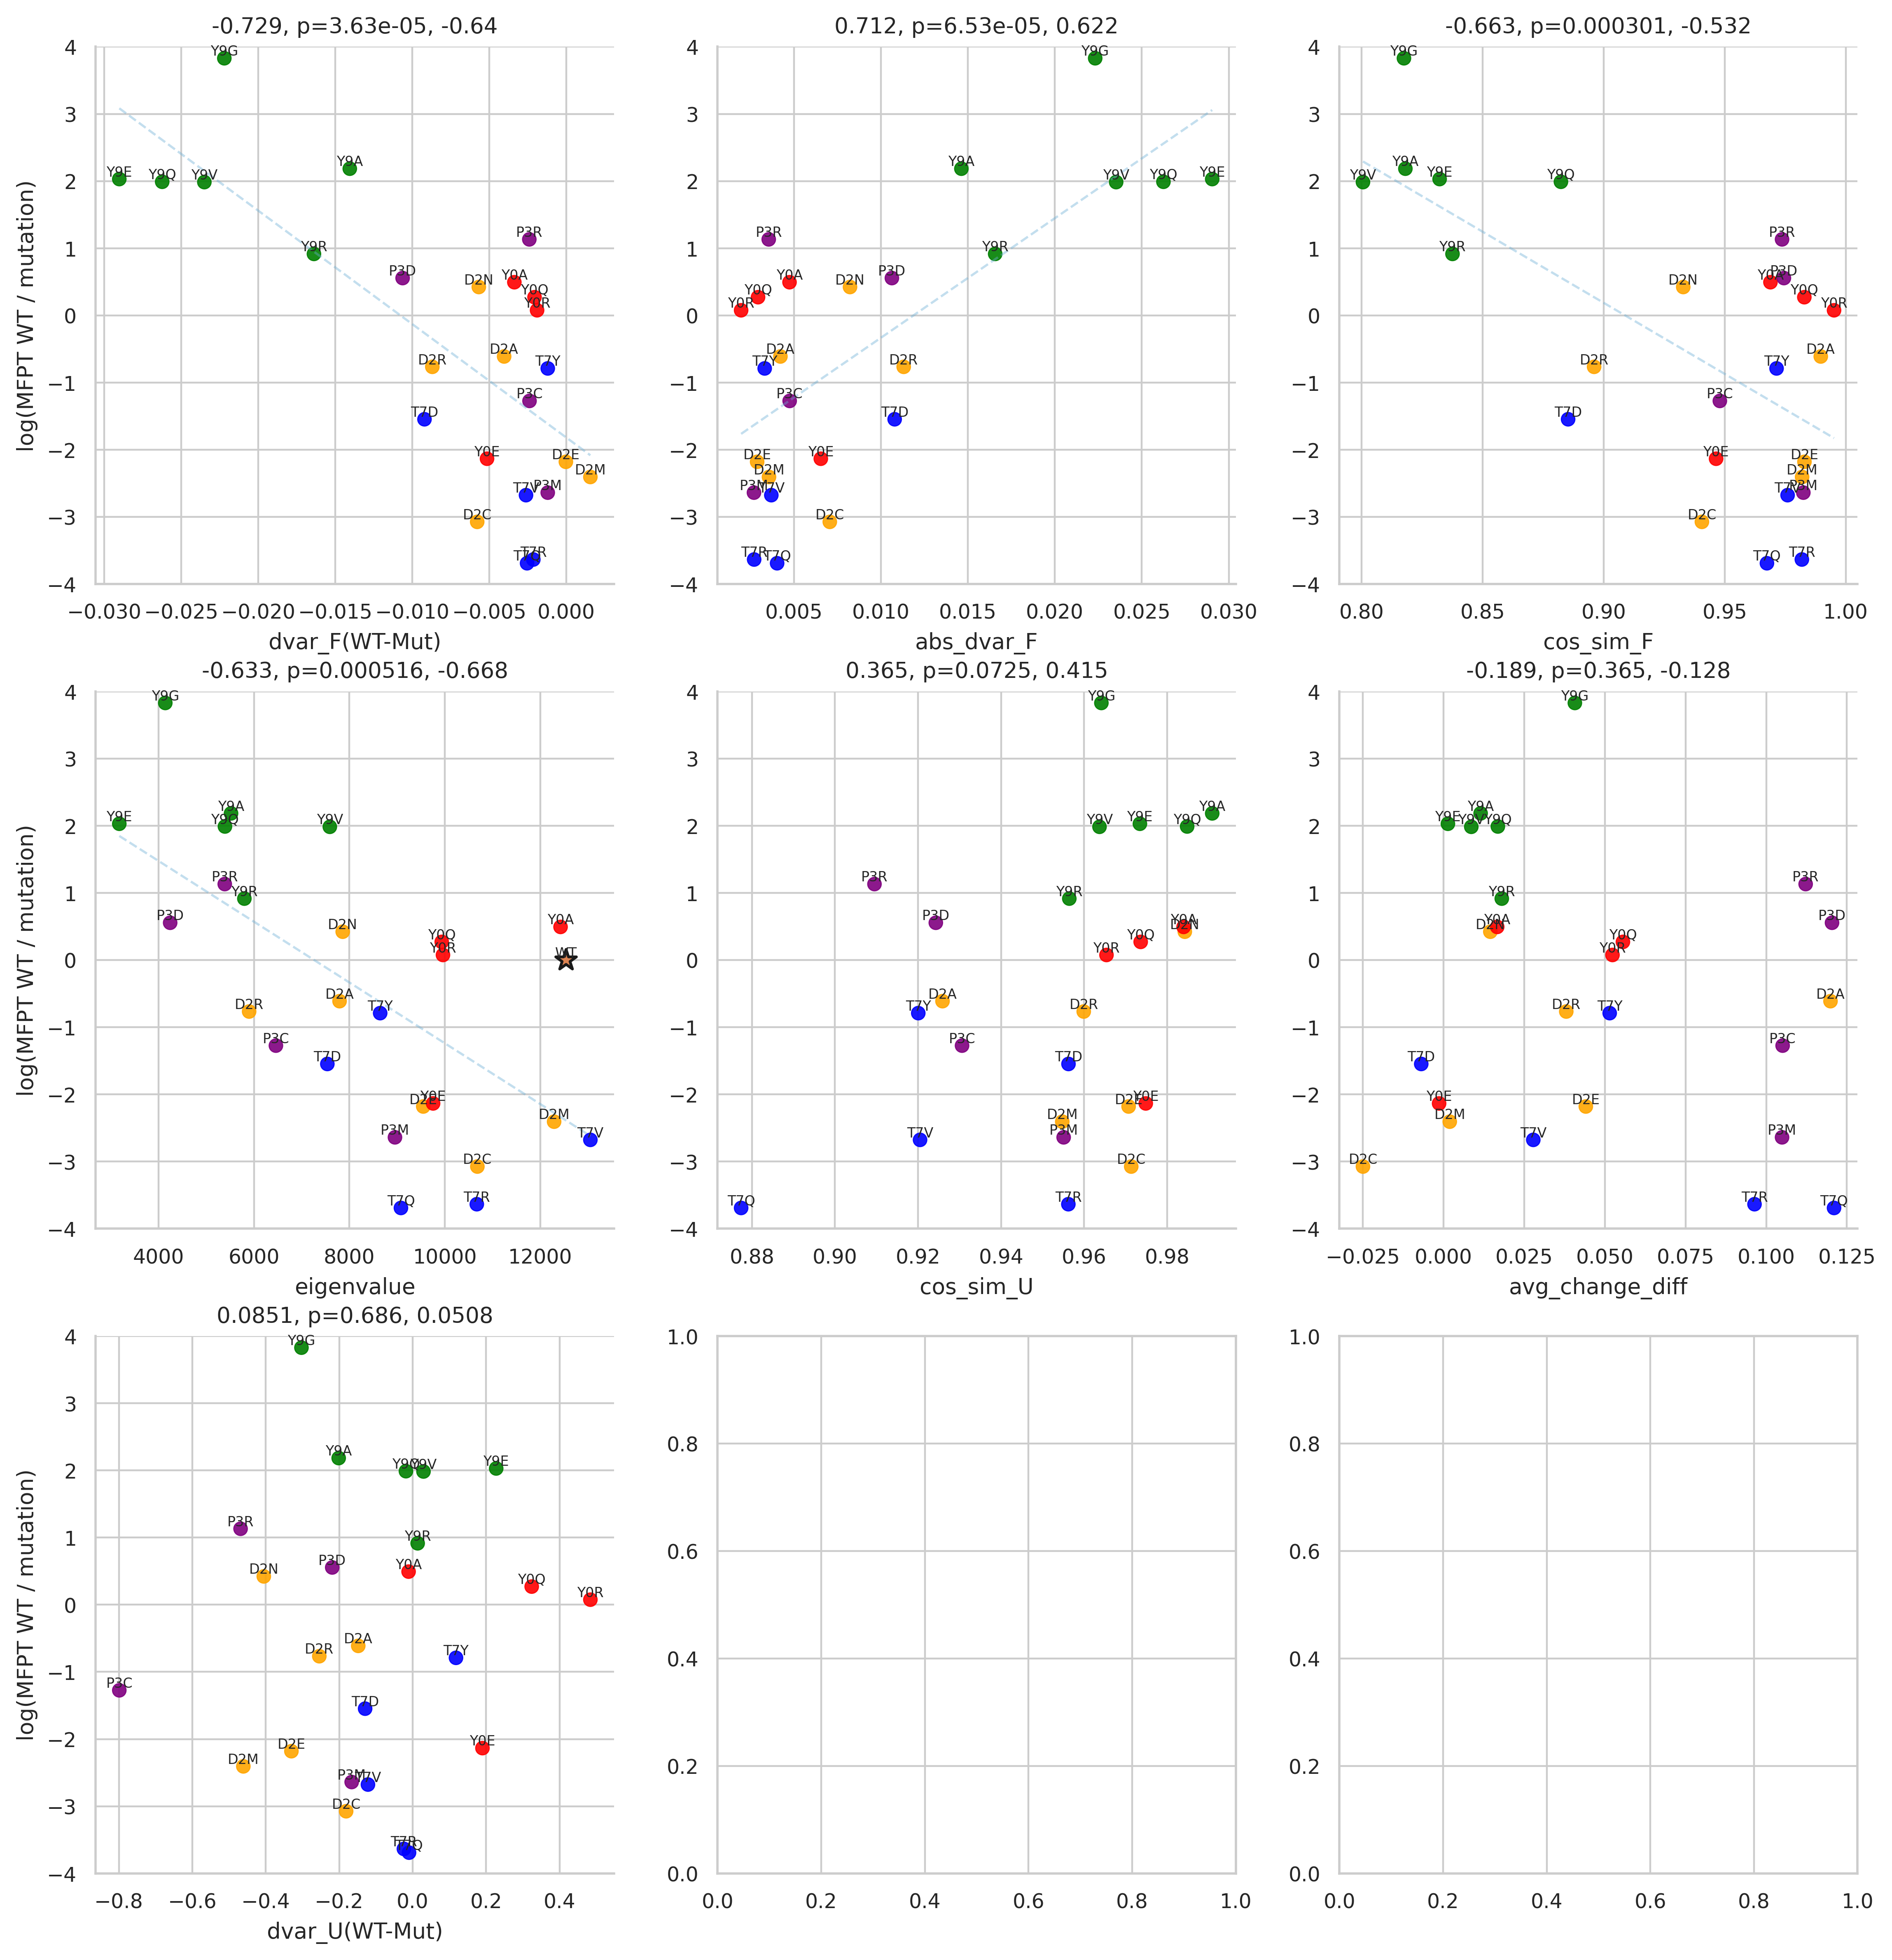

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
import pickle
from common.consts import res_colors
from common.utils import collect_df

def ratio_or_raw(wt, arr, prop_name):
    if pd.isna(wt):
        return arr
    return wt - arr if prop_name != 'tm' else np.array(wt - arr)

def plot_mfpt_corr_grid(df: pd.DataFrame, prop_cols, th=None, ncols=3):
    wt_label = 'WT'
    group_col = 'residue_idx'
    res_keys = sorted(int(k) for k in df[group_col].dropna().unique())

    wt_mfpt = float(df.loc[wt_label, 'mfpt'])
    y_all = np.log(wt_mfpt / df['mfpt'].to_numpy())
    names = df.index.to_numpy()
    wt_star = dict(s=90, marker='*', edgecolors='k', linewidths=1.2, zorder=3)

    x_cache, mask_cache, corr = {}, {}, {}

    for prop_col in prop_cols:
        x_all = df[prop_col].to_numpy()
        mask = np.isfinite(x_all) & np.isfinite(y_all)
        x_cache[prop_col] = x_all
        mask_cache[prop_col] = mask
        if mask.sum() >= 2:
            pearson_r, p = stats.pearsonr(x_all[mask], y_all[mask])
            spearman_r, _ = stats.spearmanr(x_all[mask], y_all[mask])
        else:
            pearson_r, p, spearman_r = np.nan, np.nan, np.nan
        corr[prop_col] = (pearson_r, p, spearman_r)

    ordered = sorted(
        prop_cols,
        key=lambda p: abs(corr[p][0]) if pd.notna(corr[p][0]) else -np.inf,
        reverse=True
    )
    n = len(ordered)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.6 * ncols, 4.8 * nrows),
        squeeze=False, dpi=200
    )

    for idx, prop_col in enumerate(ordered):
        ax = axes[idx // ncols][idx % ncols]
        x_all = x_cache[prop_col]
        mask = mask_cache[prop_col]
        wt_prop = df.loc[wt_label, prop_col]

        plot_df = pd.DataFrame({
            "xval": x_all,
            "yval": y_all,
            "group": df[group_col].astype("Int64").to_numpy()
        })

        pal = {k: res_colors.get(int(k)) for k in plot_df["group"].dropna().unique()}
        sns.scatterplot(
            data=plot_df, x="xval", y="yval",
            hue="group", palette=pal,
            s=35, alpha=0.9, edgecolor=None,
            legend=False, ax=ax
        )

        if not pd.isna(wt_prop):
            ax.scatter(wt_prop, 0, **wt_star)

        for xv, yv, name, m in zip(x_all, y_all, names, mask):
            if m and np.isfinite(xv) and np.isfinite(yv):
                ax.text(xv, yv, name, fontsize=6, ha='center', va='bottom')

        pearson_r, p, spearman_r = corr[prop_col]

        if pd.notna(pearson_r) and np.abs(pearson_r) > 0.5:
            sns.regplot(
                x=x_all[mask], y=y_all[mask],
                scatter=False, ci=None, ax=ax,
                color="#6baed6", line_kws={"alpha": 0.4, "lw": 1, "ls": "--"}
            )

        ax.set_xlabel(prop_col)
        if idx % ncols == 0:
            ax.set_ylabel('log(MFPT WT / mutation)')
        else:
            ax.set_ylabel('')
        ax.set_title(f"{pearson_r:.3g}, p={p:.3g}, {spearman_r:.3g}")
        ax.set_ylim(-4, 4)
        sns.despine(ax=ax)
        
props = [
    "cos_sim_F", "cos_sim_U", "avg_change_diff", "eigenvalue", "dvar_F(WT-Mut)", "dvar_U(WT-Mut)", "abs_dvar_F"
]

with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

sample_size = 200
thresholds = np.sort(np.array(list(all_mfpt['chignolin'].keys()), dtype=float))
th = thresholds[1]

df = collect_df(True, all_mfpt, th)
stats_map = plot_mfpt_corr_grid(df, props, th=th)

          d03       d04       d05       d06       d07       d08       d09  \
P3R -0.000128  0.000140  0.000571  0.000412 -0.000012  0.000096  0.000143   
T7Y  0.000006 -0.000009  0.000158  0.000708  0.000019  0.000107  0.000368   
P3C -0.000146 -0.000118 -0.000014  0.000544  0.000038  0.000046  0.000283   
D2M -0.000092  0.000120  0.000300  0.000280 -0.000052  0.000087  0.000311   
P3M -0.000135  0.000126  0.000300  0.000520  0.000068  0.000085 -0.000019   
D2C -0.000047 -0.000080  0.000131  0.000491 -0.000121  0.000050  0.000235   
Y0R  0.000021  0.000107  0.000201  0.000668 -0.000030 -0.000247 -0.000206   
T7V -0.000050 -0.000170 -0.000145  0.000332 -0.000108 -0.000048  0.000139   
Y0A -0.000157 -0.000770 -0.000999  0.000522 -0.000282 -0.000060  0.000290   
WT   0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
Y0E -0.000054 -0.000697 -0.000858  0.000693 -0.000078 -0.000052  0.000151   
T7D -0.000031  0.000034  0.000165  0.000797  0.000119  0.000224  0.000177   

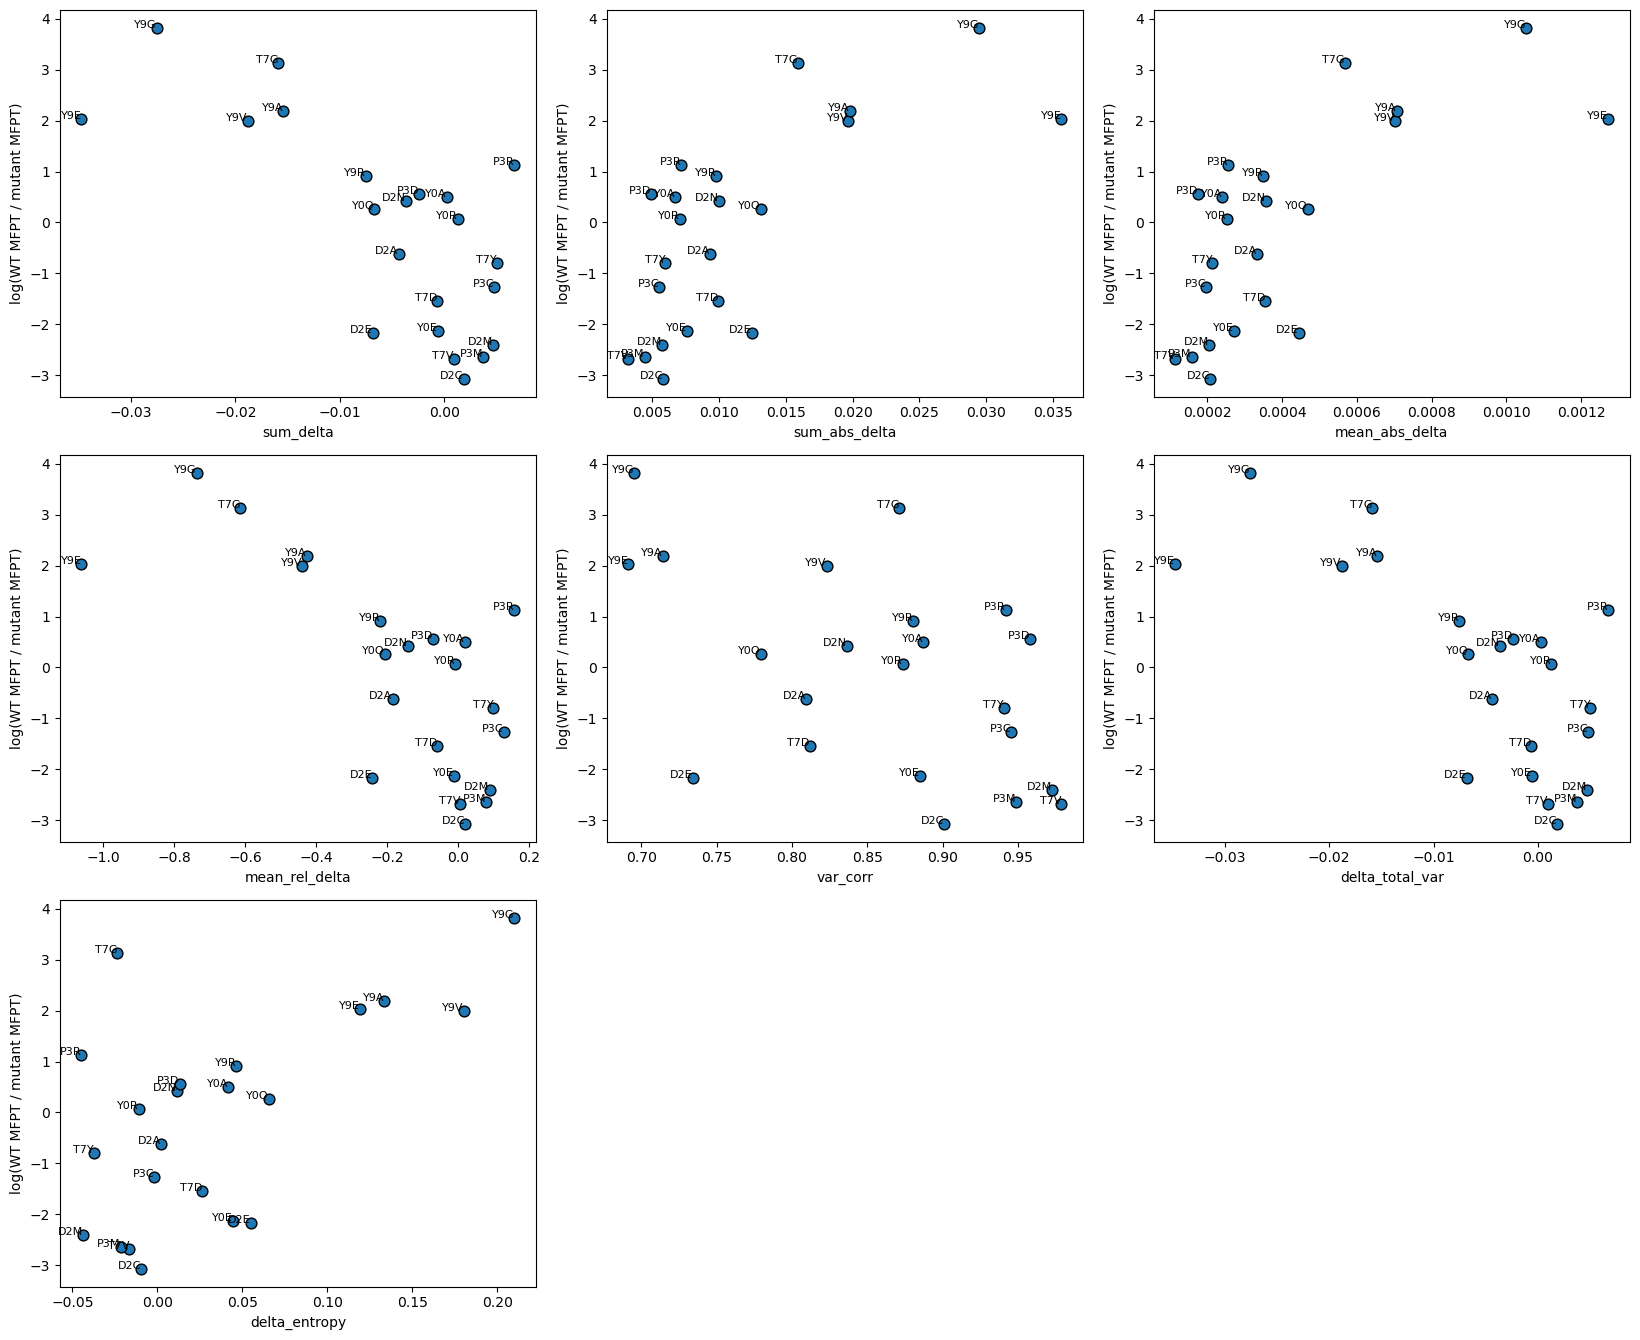